<a href="https://colab.research.google.com/github/andresalmanzal/tfm-siniestros-bogota/blob/main/notebooks/tfm_siniestros_bogota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM - Predicción de gravedad y mapa de riesgo de siniestros viales en Bogotá
**Autor:** Ovidio Almanza Ledesma · Máster en Data Science, Big Data & Business Analytics (UCM)

Notebook único y autocontenido: descarga sus propios datos y se ejecuta de principio a fin en cualquier entorno con internet. Secciones:
1. **Carga, EDA y diseño de validación**
2. **Enriquecimiento** con tablas relacionales
3. **Features** adicionales (temporales, espaciales H3, interacciones)

### Problema de negocio
Las autoridades de movilidad de Bogotá operan con presupuesto limitado (marco *Visión Cero*):
> **¿Dónde, cuándo y bajo qué condiciones es más probable un siniestro vial *grave*, para priorizar intervenciones?**

### Enfoque (híbrido)
1. Modelo supervisado de **gravedad** del siniestro, interpretado con SHAP.
2. **Productivización**: mapa de riesgo por zona, mes y día de la semana.

### Fuentes y licencia
- *Histórico Siniestros Bogotá D.C.* (capa de puntos, API Esri REST) y *Siniestros Viales Consolidados* (Excel relacional). Secretaría Distrital de Movilidad — Datos Abiertos Bogotá. Licencia **CC BY 4.0**.

In [1]:
# Configuración e imports
import io, time, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 140)
for d in ["data/raw", "data/processed"]:
    Path(d).mkdir(parents=True, exist_ok=True)
print("Entorno listo. pandas", pd.__version__)

Entorno listo. pandas 2.2.2


---
## 1. Carga, EDA y diseño de validación

### Carga reproducible (capa de puntos)
Descarga paginada vía API Esri REST (estable, sin archivos frágiles), con caché y respaldo de subida manual. Ejecuta sin configuración previa.

In [2]:
ARCGIS_URL = ("https://services2.arcgis.com/NEwhEo9GGSHXcRXV/arcgis/rest/"
              "services/HistoricoSiniestros/FeatureServer/0/query")
CACHE_PTS = Path("data/raw/historico_siniestros.parquet")

def _descargar_arcgis(url=ARCGIS_URL, page=2000, max_paginas=2000):
    regs, off = [], 0
    for _ in range(max_paginas):
        params = {"where":"1=1","outFields":"*","returnGeometry":"true","outSR":4326,
                  "f":"json","resultOffset":off,"resultRecordCount":page,"orderByFields":"OBJECTID"}
        r = requests.get(url, params=params, timeout=60); r.raise_for_status()
        feats = r.json().get("features", [])
        if not feats: break
        for ft in feats:
            a = dict(ft.get("attributes", {})); g = ft.get("geometry") or {}
            a["GEOM_LON"], a["GEOM_LAT"] = g.get("x"), g.get("y"); regs.append(a)
        off += len(feats)
        if len(feats) < page: break
    if not regs: raise RuntimeError("ArcGIS no devolvió registros.")
    return pd.DataFrame(regs)

def cargar_puntos(forzar=False):
    if CACHE_PTS.exists() and not forzar:
        print(f"[cache] {CACHE_PTS}"); return pd.read_parquet(CACHE_PTS)
    print("[descarga] capa de puntos (ArcGIS)...")
    d = _descargar_arcgis()
    try: d.to_parquet(CACHE_PTS, index=False)
    except Exception: d.to_csv(CACHE_PTS.with_suffix(".csv"), index=False)
    print(f"Filas: {len(d):,} | Columnas: {d.shape[1]}")
    return d

df_raw = cargar_puntos()
df_raw.head(2)

[descarga] capa de puntos (ArcGIS)...
Filas: 209,861 | Columnas: 19


,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,DIRECCION,GRAVEDAD,CLASE_ACC,LOCALIDAD,FECHA_HORA_ACC,LATITUD,LONGITUD,CIV,PK_CALZADA,FECHA,HORA,FECHA_HORA,GEOM_LON,GEOM_LAT
0,631773,A000405746,4453111,1470096000000,2016,KR 10-CL 11 S 02,SOLO DANOS,CHOQUE,SAN CRISTOBAL,1470096000000,4.582107,-74.089798,4000156,241544,2/08/2016,2/08/2016,None,-74.089798,4.582107
1,631774,A000759671,4509563,1519344000000,2018,AV AVENIDA DE LAS AMERICAS-KR 68 2,SOLO DANOS,CHOQUE,PUENTE ARANDA,1519344000000,4.628828,-74.122387,16004636,169764,23/02/2018,23/02/2018,None,-74.122387,4.628828


### Control de calidad temporal
Verificamos si existe hora del día. (Resultado conocido: la capa de puntos **no** trae hora —cae a medianoche—; la recuperaremos en la Sección 2 desde el Excel consolidado.)

In [3]:
for c in ["FECHA_OCURRENCIA_ACC", "FECHA_HORA_ACC"]:
    h = pd.to_datetime(pd.to_numeric(df_raw[c], errors="coerce"), unit="ms", errors="coerce").dt.hour
    print(f"{c} -> % a las 00:00 = {(h==0).mean()*100:.1f}")
print("HORA (texto) no nula:", round(df_raw['HORA'].notna().mean()*100, 3), "%")

FECHA_OCURRENCIA_ACC -> % a las 00:00 = 100.0
FECHA_HORA_ACC -> % a las 00:00 = 100.0
HORA (texto) no nula: 0.001 %


### Saneamiento defensivo
Coerción numérica explícita, normalización de texto con `unicodedata`, mapeo explícito de la gravedad y parser de fechas robusto (epoch ms). Creamos `es_grave` (1 = "Con muertos"). No se asumen dtypes ni se borran filas.

In [4]:
def normalizar_texto(serie):
    def _n(x):
        if pd.isna(x): return np.nan
        s = unicodedata.normalize("NFKD", str(x).strip().upper())
        s = "".join(c for c in s if not unicodedata.combining(c)); s = " ".join(s.split())
        return s if s else np.nan
    return serie.map(_n)

def parse_fecha(serie):
    s = pd.to_numeric(serie, errors="coerce")
    if s.notna().mean() > 0.5 and s.dropna().abs().median() > 1e10:
        return pd.to_datetime(s, unit="ms", errors="coerce")
    return pd.to_datetime(serie, errors="coerce")

df = df_raw.copy()
for col in ["GRAVEDAD","CLASE_ACC","LOCALIDAD"]:
    df[col+"_norm"] = normalizar_texto(df[col])
MAP_G = {"SOLO DANOS":"Solo daños","CON HERIDOS":"Con heridos","CON MUERTOS":"Con muertos"}
df["gravedad"] = df["GRAVEDAD_norm"].map(MAP_G)
df["es_grave"] = (df["gravedad"]=="Con muertos").astype("Int64")
df["lat"] = pd.to_numeric(df["LATITUD"], errors="coerce").fillna(pd.to_numeric(df["GEOM_LAT"], errors="coerce"))
df["lon"] = pd.to_numeric(df["LONGITUD"], errors="coerce").fillna(pd.to_numeric(df["GEOM_LON"], errors="coerce"))
df["fecha_hora"] = parse_fecha(df["FECHA_HORA_ACC"])
df["anio"] = pd.to_numeric(df["ANO_OCURRENCIA_ACC"], errors="coerce").fillna(df["fecha_hora"].dt.year).astype("Int64")
df["mes"] = df["fecha_hora"].dt.month
df["dia_semana"] = df["fecha_hora"].dt.dayofweek
df["CODIGO_ACCIDENTE"] = pd.to_numeric(df["CODIGO_ACCIDENTE"], errors="coerce").astype("Int64")
print("Base saneada:", df.shape)

Base saneada: (209861, 30)


### EDA - target, clase, tiempo y espacio

In [5]:
# Target (desbalance) y clase x gravedad
print(pd.concat([df["gravedad"].value_counts().rename("conteo"),
                 (df["gravedad"].value_counts(normalize=True)*100).round(2).rename("%")], axis=1))
print("\nGravedad por clase (% fila):")
print((pd.crosstab(df["CLASE_ACC_norm"], df["gravedad"], normalize="index")*100).round(1))

             conteo      %
gravedad                  
Solo daños   134812  64.24
Con heridos   71656  34.14
Con muertos    3393   1.62

Gravedad por clase (% fila):
gravedad           Con heridos  Con muertos  Solo daños
CLASE_ACC_norm                                         
ATROPELLO                 92.5          7.2         0.2
AUTOLESION               100.0          0.0         0.0
CAIDA DE OCUPANTE         98.8          0.8         0.4
CHOQUE                    24.7          0.9        74.5
INCENDIO                  12.5          0.0        87.5
OTRO                      84.4          0.8        14.8
VOLCAMIENTO               74.5          9.7        15.8


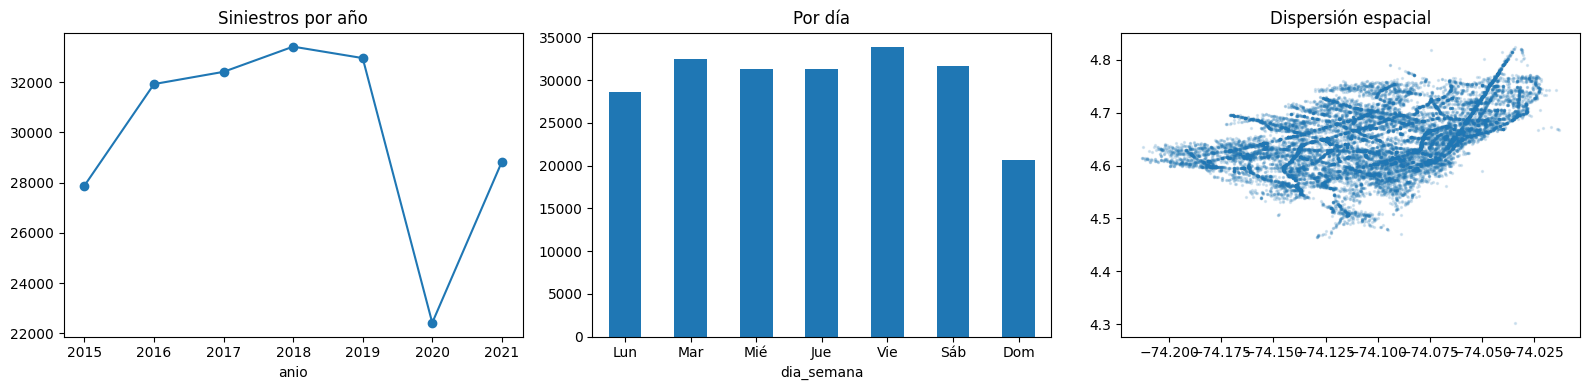

Coordenadas válidas: 100.00%

Top localidades (tasa fatal %):
                siniestros  tasa_fatal
LOCALIDAD_norm                        
KENNEDY              25116        1.89
ENGATIVA             22085        1.40
USAQUEN              20109        0.86
SUBA                 20021        1.39
FONTIBON             17279        1.42
PUENTE ARANDA        14957        1.61
CHAPINERO            12153        0.80
TEUSAQUILLO          10657        1.10
BARRIOS UNIDOS       10593        1.03
BOSA                  9922        2.13


In [6]:
# Patrones temporales y espaciales
fig, ax = plt.subplots(1, 3, figsize=(16,4))
df.groupby("anio").size().plot(ax=ax[0], marker="o"); ax[0].set_title("Siniestros por año")
dias=["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]
df.groupby("dia_semana").size().reindex(range(7)).plot(kind="bar", ax=ax[1]); ax[1].set_xticklabels(dias,rotation=0); ax[1].set_title("Por día")
def _bbox(lat,lon): return lat.between(4.0,4.9)&lon.between(-74.30,-73.95)
df["coord_valida"]=_bbox(df["lat"],df["lon"])
m=df[df["coord_valida"]].sample(min(20000,int(df["coord_valida"].sum())),random_state=SEED)
ax[2].scatter(m["lon"],m["lat"],s=2,alpha=0.15); ax[2].set_title("Dispersión espacial")
plt.tight_layout(); plt.show()
print("Coordenadas válidas:", f"{df['coord_valida'].mean()*100:.2f}%")
print("\nTop localidades (tasa fatal %):")
print(df.groupby("LOCALIDAD_norm").agg(siniestros=("OBJECTID","size"),
      tasa_fatal=("es_grave", lambda s: round(s.mean()*100,2))).sort_values("siniestros",ascending=False).head(10))

### Métrica y validación (fijadas ANTES de modelar)
**Métrica:** la clase fatal es ~1,6 %, así que la exactitud queda descartada. Se usa **F1 macro** (selección), **recall de "Con muertos"** (negocio) y **PR-AUC** por clase; se reporta matriz de confusión.

**Validación:** **partición temporal** (no aleatoria) - train 2015–2018, validación 2019, test 2021, **2020 excluido** (COVID). Todo ajuste se aprende solo en *train*.

In [7]:
def particion_temporal(d, excluir=(2020,)):
    anios = sorted(int(a) for a in d["anio"].dropna().unique() if int(a) not in excluir)
    test, val = anios[-1:], anios[-2:-1]
    train = [a for a in anios if a not in test+val]
    return {"train":train,"val":val,"test":test,"excluidos":list(excluir)}
part = particion_temporal(df); print("Partición:", part)
for n,a in [("train",part["train"]),("val",part["val"]),("test",part["test"])]:
    sub=df[df["anio"].isin(a)]; print(f"  {n:5s} {a}: {len(sub):,} | %fatal {sub['es_grave'].mean()*100:.2f}")

Partición: {'train': [2015, 2016, 2017, 2018], 'val': [2019], 'test': [2021], 'excluidos': [2020]}
  train [2015, 2016, 2017, 2018]: 125,646 | %fatal 1.65
  val   [2019]: 32,962 | %fatal 1.50
  test  [2021]: 28,829 | %fatal 1.59


---
## 2. Enriquecimiento con tablas relacionales

Unimos por **`CODIGO_ACCIDENTE`** las tablas del Excel *Consolidados* (SINIESTROS, ACTOR_VIAL, VEHICULOS, HIPOTESIS, DICCIONARIO). **Recuperamos la hora del día** (en `SINIESTROS.HORA`). **`ESTADO`** (ileso/herido/muerto) se **excluye** por fuga de datos.

> **Nota de reproducibilidad:** el portal a veces rechaza conexiones desde IP de centros de datos (p. ej. ciertas sesiones de Colab) y la descarga del Excel cae en *timeout*; en un entorno local funciona. Hay subida manual de respaldo; el archivo queda en caché.

In [8]:
XLSX_URL = ("https://datosabiertos.bogota.gov.co/dataset/0b070626-fe5a-42dc-ae99-92601da166d9/"
            "resource/9e3add8e-3f46-42ce-9c0f-419964f6f598/download/siniestros_viales_consolidados_bogota_dc.xlsx")
XLSX_PATH = Path("data/raw/siniestros_consolidados.xlsx")

def descargar_xlsx(url=XLSX_URL, path=XLSX_PATH, intentos=2):
    if path.exists(): print(f"[cache] {path}"); return path
    hdr={"User-Agent":"Mozilla/5.0 (TFM)","Accept":"*/*"}
    for i in range(1,intentos+1):
        try:
            r=requests.get(url,headers=hdr,timeout=(20,300),allow_redirects=True); r.raise_for_status()
            path.write_bytes(r.content); print(f"[guardado] {path} ({path.stat().st_size/1e6:.1f} MB)"); return path
        except Exception as e: print(f"  falló intento {i}: {type(e).__name__}")
    print("Descarga automática no disponible. Sube el .xlsx (bájalo del navegador):")
    from google.colab import files
    up=files.upload(); path.write_bytes(up[next(iter(up))]); return path

ruta = descargar_xlsx()
hojas = pd.read_excel(ruta, sheet_name=None)
print("Hojas:", list(hojas.keys()))

[guardado] data/raw/siniestros_consolidados.xlsx (49.2 MB)
Hojas: ['SINIESTROS', 'ACTOR_VIAL', 'VEHICULOS', 'HIPOTESIS', 'DICCIONARIO']


In [9]:
# Diccionario de decodificación
dicc = hojas["DICCIONARIO"].copy()
dicc.columns=[str(c).strip().upper() for c in dicc.columns]
for c in ["HOJA","CAMPO"]: dicc[c]=dicc[c].astype(str).str.strip().str.upper()
dicc["CODIGO"]=pd.to_numeric(dicc["CODIGO"],errors="coerce")
DECODE={}
for (h,c),g in dicc.dropna(subset=["CODIGO"]).groupby(["HOJA","CAMPO"]):
    DECODE[(h,c)]=dict(zip(g["CODIGO"].astype(int), g["DESCRIPCION"].astype(str).str.strip()))
def decodificar(serie,hoja,campo):
    m=DECODE.get((hoja.upper(),campo.upper()))
    if not m: print(f"  [aviso] sin diccionario para {hoja}.{campo}"); return serie
    return pd.to_numeric(serie,errors="coerce").map(m)
print("Pares decodificables:", len(DECODE))

Pares decodificables: 10


In [10]:
# SINIESTROS -> hora recuperada, franja y diseño del lugar
sin = hojas["SINIESTROS"].copy()
sin["CODIGO_ACCIDENTE"]=pd.to_numeric(sin["CODIGO_ACCIDENTE"],errors="coerce").astype("Int64")
sin["hora"]=pd.to_datetime(sin["HORA"].astype(str).str.strip(), format="%H:%M:%S", errors="coerce").dt.hour
def franja(h):
    if pd.isna(h): return np.nan
    h=int(h); return "Madrugada" if h<6 else "Mañana" if h<12 else "Tarde" if h<18 else "Noche"
sin["franja_horaria"]=sin["hora"].map(franja)
sin["diseno_lugar"]=decodificar(sin["DISENO_LUGAR"],"SINIESTROS","DISENO_LUGAR").astype("string")
sin_feats=sin[["CODIGO_ACCIDENTE","hora","franja_horaria","diseno_lugar"]].drop_duplicates("CODIGO_ACCIDENTE")
print("Hora recuperada -> % no nula:", round(sin_feats["hora"].notna().mean()*100,1))

Hora recuperada -> % no nula: 100.0


In [11]:
# VEHICULOS -> agregación por siniestro
veh=hojas["VEHICULOS"].copy()
veh["CODIGO_ACCIDENTE"]=pd.to_numeric(veh["CODIGO_ACCIDENTE"],errors="coerce").astype("Int64")
veh["cd"]=decodificar(veh["CLASE"],"VEHICULOS","CLASE").astype("string").str.upper()
for kw,col in [("MOTO","es_moto"),("BICI","es_bici"),("BUS","es_bus"),("CAMION","es_camion")]:
    veh[col]=veh["cd"].str.contains(kw,na=False)
veh_agg=veh.groupby("CODIGO_ACCIDENTE").agg(n_vehiculos=("VEHICULO","count"),
    involucra_moto=("es_moto","max"),involucra_bici=("es_bici","max"),
    involucra_bus=("es_bus","max"),involucra_camion=("es_camion","max")).reset_index()

# ACTOR_VIAL -> agregación SIN ESTADO (fuga)
act=hojas["ACTOR_VIAL"].copy()
act["CODIGO_ACCIDENTE"]=pd.to_numeric(act["CODIGO_ACCIDENTE"],errors="coerce").astype("Int64")
act["CONDICION"]=act["CONDICION"].astype("string").str.strip().str.upper()
act["EDAD"]=pd.to_numeric(act["EDAD"],errors="coerce")
for kw,col in [("PEATON","es_peaton"),("MOTO","es_motoc"),("CICLISTA","es_cicl"),("PASAJERO","es_pas")]:
    act[col]=act["CONDICION"].str.contains(kw,na=False)
act_agg=act.groupby("CODIGO_ACCIDENTE").agg(n_actores=("CODIGO_ACCIDENTADO","count"),
    involucra_peaton=("es_peaton","max"),involucra_motociclista=("es_motoc","max"),
    involucra_ciclista=("es_cicl","max"),involucra_pasajero=("es_pas","max"),
    edad_min=("EDAD","min"),edad_prom=("EDAD","mean")).reset_index()

# HIPOTESIS -> causa principal (moda)
hip=hojas["HIPOTESIS"].copy()
hip["CODIGO_ACCIDENTE"]=pd.to_numeric(hip["CODIGO_ACCIDENTE"],errors="coerce").astype("Int64")
hip["cd"]=decodificar(hip["CODIGO_CAUSA"],"HIPOTESIS","CODIGO_CAUSA").astype("string").str.strip()
def _moda(s):
    s=s.dropna(); return s.mode().iloc[0] if not s.mode().empty else np.nan
hip_agg=hip.groupby("CODIGO_ACCIDENTE").agg(n_hipotesis=("CODIGO_CAUSA","count"),
    causa_principal=("cd",_moda)).reset_index()
print("Agregados listos:", veh_agg.shape, act_agg.shape, hip_agg.shape)

Agregados listos: (196004, 6) (196004, 8) (195735, 3)


In [12]:
# UNIÓN sobre la base (left join), cobertura y relleno de banderas
codigos = df["CODIGO_ACCIDENTE"]
df = (df.merge(sin_feats,on="CODIGO_ACCIDENTE",how="left")
        .merge(veh_agg,on="CODIGO_ACCIDENTE",how="left")
        .merge(act_agg,on="CODIGO_ACCIDENTE",how="left")
        .merge(hip_agg,on="CODIGO_ACCIDENTE",how="left"))
print("Cobertura del enriquecimiento:")
for n,a in [("SINIESTROS/hora",sin_feats),("VEHICULOS",veh_agg),("ACTOR_VIAL",act_agg),("HIPOTESIS",hip_agg)]:
    print(f"  {n:16s}: {codigos.isin(a['CODIGO_ACCIDENTE']).mean()*100:5.1f}%")
flags=[c for c in df.columns if c.startswith("involucra_")]
df[flags]=df[flags].fillna(False).astype(bool)
print("Enriquecido:", df.shape)

Cobertura del enriquecimiento:
  SINIESTROS/hora :  86.3%
  VEHICULOS       :  86.2%
  ACTOR_VIAL      :  86.2%
  HIPOTESIS       :  86.1%
Enriquecido: (209861, 48)


---
## 3. Features adicionales

Temporales (fin de semana, festivo, cíclicas), espaciales (**malla H3**), interacciones y **agrupamiento temático de la causa**. Solo features que **no usan el target**: la tasa de letalidad por zona se calculará dentro de la validación cruzada (solo en *train*) en el modelado.

In [13]:
!pip install -q h3 holidays
import h3, holidays as hol
_to_cell = getattr(h3, "latlng_to_cell", None) or h3.geo_to_h3
festivos_co = hol.country_holidays("CO")

# Temporales
df["es_fin_semana"]=df["dia_semana"].isin([5,6])
df["es_festivo"]=df["fecha_hora"].dt.date.map(lambda d:(d in festivos_co) if pd.notna(d) else False)
df["es_finde_o_festivo"]=df["es_fin_semana"]|df["es_festivo"]
df["hora_sin"]=np.sin(2*np.pi*df["hora"]/24); df["hora_cos"]=np.cos(2*np.pi*df["hora"]/24)
df["mes_sin"]=np.sin(2*np.pi*df["mes"]/12);   df["mes_cos"]=np.cos(2*np.pi*df["mes"]/12)

# Espaciales H3 (res7 zona, res8 barrio)
def asignar_h3(d,res):
    out=np.full(len(d),None,dtype=object)
    m=(d["lat"].notna()&d["lon"].notna()).to_numpy()
    la=d["lat"].to_numpy(); lo=d["lon"].to_numpy(); idx=np.where(m)[0]
    out[idx]=[_to_cell(la[i],lo[i],res) for i in idx]; return out
df["h3_res7"]=asignar_h3(df,7); df["h3_res8"]=asignar_h3(df,8)

# Interacciones
fr_noche=df["franja_horaria"].isin(["Noche","Madrugada"])
dis=df["diseno_lugar"].astype("string")
df["moto_noche"]=df["involucra_moto"].fillna(False)&fr_noche
df["peaton_interseccion"]=df["involucra_peaton"].fillna(False)&dis.str.contains("INTERSEC",case=False,na=False)
df["bici_finde"]=df["involucra_bici"].fillna(False)&df["es_fin_semana"]
print("Festivos:",int(df["es_festivo"].sum()),"| celdas res8:",df["h3_res8"].nunique())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.9 MB/s eta 0:00:00
Festivos: 5645 | celdas res8: 605


In [14]:
# Agrupamiento temático de la causa (limpio) + indicador de datos faltantes
def _nc(x):
    if pd.isna(x): return ""
    x=unicodedata.normalize("NFKD",str(x).lower()); return "".join(c for c in x if not unicodedata.combining(c))
def agrupar_causa(c):
    if pd.isna(c): return "Sin dato"
    t=_nc(c)
    if any(k in t for k in ["embriag","alcohol","drog"]): return "Embriaguez/sustancias"
    if "exceso" in t or "velocidad" in t:                 return "Exceso de velocidad"
    if "distancia" in t:                                  return "No mantener distancia"
    if "adelantar" in t:                                  return "Adelantamiento indebido"
    if any(k in t for k in ["semaforo","senal","prelacion","rojo","pare"]): return "Desobedecer señales/prelación"
    if "peaton" in t or "cruzar" in t:                    return "Conducta del peatón"
    if any(k in t for k in ["reverso","girar","arrancar","marcha","transitar entre","zigzag","invadiendo","carril","brusc"]):
        return "Maniobra/giro imprudente"
    return "Otra / no especificada"
df["grupo_causa"]=df["causa_principal"].map(agrupar_causa)
df["sin_dato_relacional"]=df["n_actores"].isna()
print(df["grupo_causa"].value_counts(dropna=False))
print("\nSin dato relacional:", f"{df['sin_dato_relacional'].mean()*100:.1f}%")

grupo_causa
No mantener distancia            43206
Adelantamiento indebido          37289
Otra / no especificada           35760
Desobedecer señales/prelación    30865
Sin dato                         29231
Maniobra/giro imprudente         17532
Conducta del peatón              10258
Embriaguez/sustancias             4039
Exceso de velocidad               1681
Name: count, dtype: int64

Sin dato relacional: 13.8%


### Persistencia del dataset modelable
Guardamos el dataset final. En la siguiente fase (modelado) se añadirá a este mismo notebook la selección de variables, la codificación, el entrenamiento y la interpretabilidad.

In [15]:
COLS = ["OBJECTID","CODIGO_ACCIDENTE","gravedad","es_grave","CLASE_ACC_norm","LOCALIDAD_norm",
        "fecha_hora","anio","mes","dia_semana","hora","franja_horaria","es_fin_semana",
        "es_festivo","es_finde_o_festivo","hora_sin","hora_cos","mes_sin","mes_cos",
        "lat","lon","coord_valida","h3_res7","h3_res8","diseno_lugar",
        "n_vehiculos","involucra_moto","involucra_bici","involucra_bus","involucra_camion",
        "n_actores","involucra_peaton","involucra_motociclista","involucra_ciclista","involucra_pasajero",
        "edad_min","edad_prom","n_hipotesis","causa_principal","grupo_causa",
        "moto_noche","peaton_interseccion","bici_finde","sin_dato_relacional"]
final = df[[c for c in COLS if c in df.columns]].copy()
dest = Path("data/processed/siniestros_modelable.parquet")
try: final.to_parquet(dest,index=False); print(f"Guardado: {dest} | {final.shape}")
except Exception as e:
    dest=dest.with_suffix(".csv"); final.to_csv(dest,index=False); print(f"CSV: {dest} | {final.shape}")

Guardado: data/processed/siniestros_modelable.parquet | (209861, 44)


### Resumen
Pipeline reproducible de extremo a extremo: carga (209.861 siniestros, 2015–2021) → EDA y validación temporal → enriquecimiento relacional (recuperando la hora del día, sin fuga de `ESTADO`) → features temporales/espaciales/interacciones y causa agrupada. **Siguiente:** modelado (baseline → modelos, métricas y SHAP) y mapa de riesgo, que se añadirán a este mismo notebook.

> **Hallazgos (causa agrupada):** la causa se consolidó en 9 grupos temáticos. Predominan fallos de conducción: no mantener distancia (43.206), adelantamiento indebido (37.289), desobedecer señales/prelación (30.865) y maniobras/giros imprudentes (17.532). La conducta del peatón aparece en 10.258 casos. Llama la atención que **embriaguez (4.039) y exceso de velocidad (1.681) estén sub-registrados** —algo típico del IPAT, donde estas causas no siempre se consignan—, un sesgo de la fuente que conviene tener presente. "Otra / no especificada" (35.760) y "Sin dato" (29.231) suman ~31 %, limitación inherente del registro que se documenta y se marca con `sin_dato_relacional`.